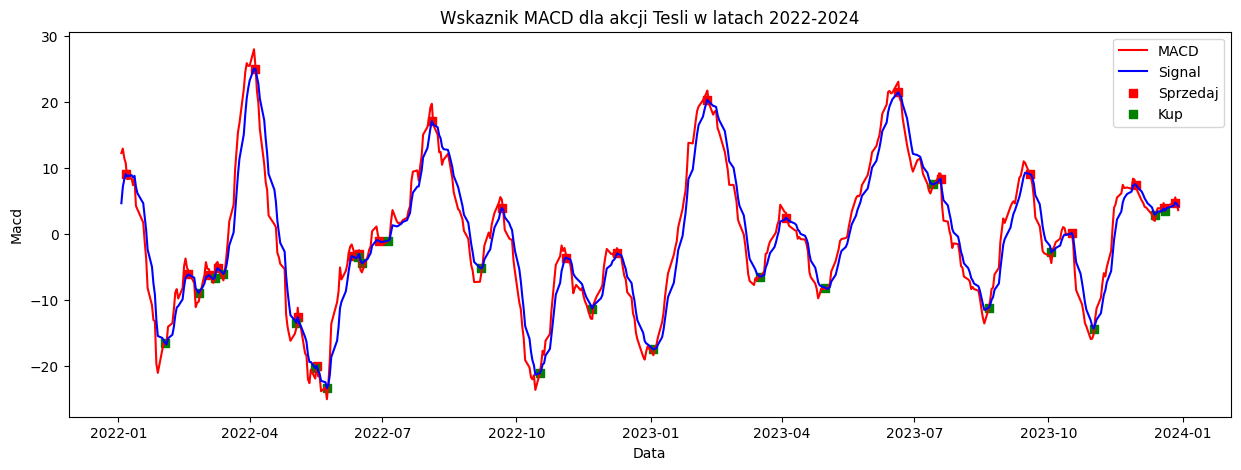

In [2]:
import matplotlib.pyplot as plt
import main
%matplotlib inline

data = main.get_data()
plt.figure(figsize=(15, 5))
data = data[(data['Date'] >= '2022-01-01') & (data['Date'] <= '2024-01-01')]
plt.plot(data['Date'], data['Macd'], color='red')
plt.plot(data['Date'], data['Signal'], color='blue')
intersect_over = data[(data['MacdSignalDiff'] > 0) & (data['DidCross'] == 1)]
intersect_below = data[(data['MacdSignalDiff'] < 0) & (data['DidCross'] == 1)]
plt.scatter(intersect_over['Date'], intersect_over['Signal'], marker='s', color='red')
plt.scatter(intersect_below['Date'], intersect_below['Signal'], marker='s', color='green')

plt.title('Wskaznik MACD dla akcji Tesli w latach 2022-2024')
plt.xlabel('Data')
plt.ylabel('Macd')
plt.legend(['MACD', 'Signal', 'Sprzedaj', 'Kup'])

plt.show()


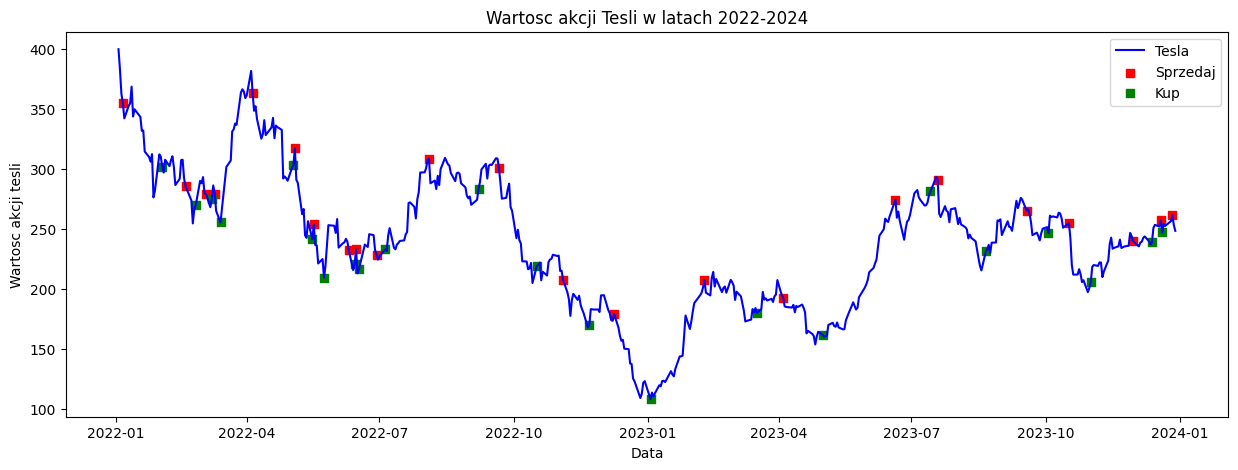

In [12]:
plt.figure(figsize=(15, 5))
data = main.get_data()
data = data[(data['Date'] >= '2022-01-01') & (data['Date'] <= '2024-01-01')]
plt.plot(data['Date'], data['Stock'], color='blue')
intersect_over = data[(data['MacdSignalDiff'] > 0) & (data['DidCross'] == 1)]
intersect_below = data[(data['MacdSignalDiff'] < 0) & (data['DidCross'] == 1)]
plt.scatter(intersect_over['Date'], intersect_over['Stock'], marker='s', color='red')
plt.scatter(intersect_below['Date'], intersect_below['Stock'], marker='s', color='green')

plt.title("Wartosc akcji Tesli w latach 2022-2024")
plt.xlabel('Data')
plt.ylabel('Wartosc akcji tesli')
plt.legend(['Tesla', 'Sprzedaj', 'Kup'])

plt.show()


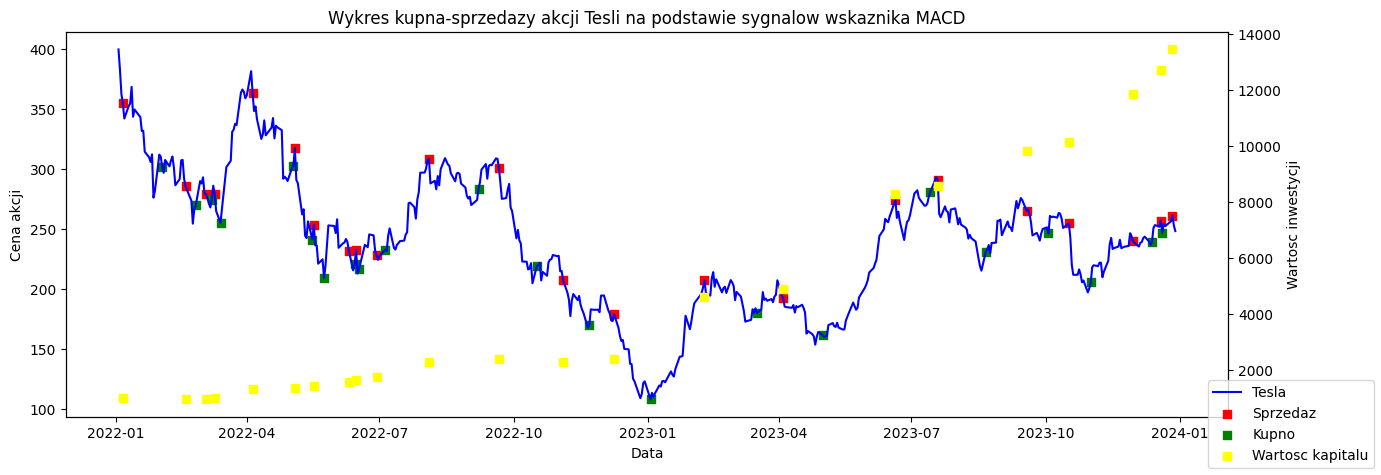

In [2]:
data = main.get_data()
data = data[(data['Date'] >= '2022-01-01') & (data['Date'] <= '2024-01-01')]

intersect_over = data[(data['MacdSignalDiff'] > 0) & (data['DidCross'] == 1)]
intersect_below = data[(data['MacdSignalDiff'] < 0) & (data['DidCross'] == 1)]

crosses = data[data['DidCross'] == 1]
sell = data[(data['DidCross'] == 1) & (data['MacdSignalDiff'] >= 0)]
money = main.simulate(crosses)

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(data['Date'], data['Stock'], color='blue')
ax1.scatter(intersect_over['Date'], intersect_over['Stock'], marker='s', color='red')
ax1.scatter(intersect_below['Date'], intersect_below['Stock'], marker='s', color='green')

ax2 = ax1.twinx()
ax2.scatter(sell['Date'], money, marker="s", color="yellow")

ax1.set_ylabel("Cena akcji")
ax2.set_ylabel("Wartosc inwestycji")
ax1.set_xlabel("Data")
ax1.set_title("Wykres kupna-sprzedazy akcji Tesli na podstawie sygnalow wskaznika MACD")
fig.legend(["Tesla", "Sprzedaz", "Kupno", "Wartosc kapitalu"], loc="lower right")

plt.show()
